In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,                
    "font.family": "serif",
    "font.serif": ["Computer Modern"],
    "figure.dpi": 150,                   
    "grid.alpha": 0.4,                    
})

# Hadronic Dark Matter (EoS II)

In [ ]:
# =========================================================
# 1. Thermodynamic relation for polytropes
# =========================================================
def _energy_polytrope(p, gamma, mu0, n0, p0):

    term1 = (1 / (gamma - 1)) * p
    term2_coefficient = (mu0 * n0) - (gamma / (gamma - 1)) * p0
    pressure_ratio = (p / p0) ** (1 / gamma)
    return term1 + (term2_coefficient * pressure_ratio)

# =========================================================
# 2. Main function to generate the Hadronic EoS II
# =========================================================

def generate_hadronic_eos2(B_val_MeV4, crust_file_path="../Data/BPSxEFTeos2.txt", N=1000):
    """
    Generates the Hadronic Equation of State (EoS II) combining the crust
    with two core polytropes, and scales it to 4B units.
    """
    n_sat = 0.16 # fm^-3
    
    # 1. Load Crust Data
    column_names = ['n_n0', 'rho_c2', 'pressure', 'energy_density']
    df_crust = pd.read_csv(crust_file_path, sep='\s+', comment='#', header=None, names=column_names)  
    p_crust = df_crust['pressure'].values
    e_crust = df_crust['energy_density'].values
    
    # 2. First Polytrope (Core 1)
    Gamma_1 = 4.021
    mu_0_1 = 0.9775 * 1000 # MeV
    n_0_1 = 1.1 * n_sat 
    p_0_1 = 3.542 # MeV/fm^3
    p_0_2 = 129.7 # MeV/fm^3
    
    p_core1 = np.geomspace(p_0_1, p_0_2, N)
    e_core1 = _energy_polytrope(p_core1, Gamma_1, mu_0_1, n_0_1, p_0_1)
    
    # 3. Second Polytrope (Core 2)
    Gamma_2 = 1.195
    mu_0_2 = 1.351 * 1000 # MeV
    n_0_2 = 2.7 * n_sat 
    pmax = 1e4 # MeV/fm^3
    
    p_core2 = np.geomspace(p_0_2, pmax, N)
    e_core2 = _energy_polytrope(p_core2, Gamma_2, mu_0_2, n_0_2, p_0_2)
    
    # 4. Stitch them together 
    grid_p = np.concatenate((p_crust[:-1], p_core1[:-1], p_core2))
    grid_e = np.concatenate((e_crust[:-1], e_core1[:-1], e_core2))
    
    # 5. Apply Scaling (Convert from physical MeV/fm^3 to 4B Dimensionless units)
    hc = 197.3269804 # MeV fm
    scale_pe = hc**3 / (4 * B_val_MeV4)
    
    df = pd.DataFrame({
        'Energy_Density': grid_e * scale_pe,
        'Pressure': grid_p * scale_pe
    })
    
    return df

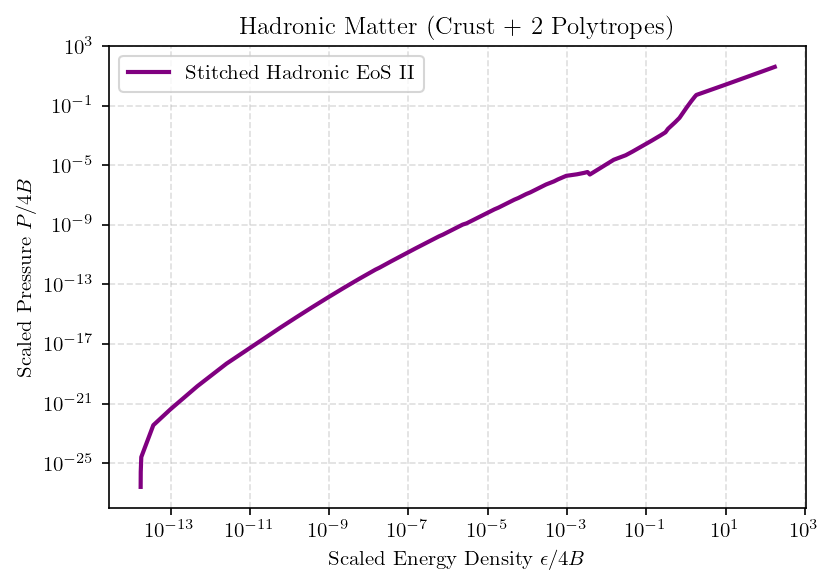

In [6]:
# =========================================================
# Configuration & Generation
# =========================================================
B_MeV = 148.0
B_val_MeV4 = B_MeV**4


# Generate the EoS
df_hadronic = generate_hadronic_eos2(B_val_MeV4, crust_file_path="../data/input/BPSxEFTeos2.txt")


# =========================================================
# Plotting
# =========================================================
plt.figure(figsize=(6,4))
plt.plot(df_hadronic['Energy_Density'], df_hadronic['Pressure'], 
         label='Stitched Hadronic EoS II', color='purple', lw=2)

plt.xlabel(r'Scaled Energy Density $\epsilon / 4B$')
plt.ylabel(r'Scaled Pressure $P / 4B$')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.title('Hadronic Matter (Crust + 2 Polytropes)')
plt.show()


In [7]:
name_B = int(B_MeV)
name_csv = f'../data/eos_library/hadronic_EOSII_B_{name_B}.csv'
df_hadronic.to_csv(name_csv, index=False)
